# Jet Lens — GPT-2 Large

Compares the **iterative jet lens** at orders $k=0, 1, 2$ with the classical **logit lens** ($k=0$).

For each layer $l$, the iterative jet lens approximates the decoder output with a $k$-th order Taylor expansion centred at the residual stream $h_l$:
$$
\hat{f}_l(z) = \sum_{j=0}^{k} \frac{1}{j!}\, (\mathrm{ln} \circ h_L)^{(j)}(h_l(z))\cdot(h_l(z))^j
$$
Order $k=0$ is exactly the logit lens.

In [1]:
import torch
import jex.models as models
from jex.lenses.iterative import IterativeJetLenses
from jex.lenses.joint import JointJetLens
from jex.lenses.utils import plot_lens_table, plot_joint_lens_table

## Load model

In [2]:
# model_name = 'gpt2'
model_name = "EleutherAI/gpt-neo-2.7B"
lm = models.from_pretrained(model_name)
layers = list(range(1, lm.depth + 1))
print(f"Loaded {lm.name}: {lm.depth} layers, vocab size {lm.vocab_size}")

Loading weights:   0%|          | 0/420 [00:00<?, ?it/s]

GPTNeoForCausalLM LOAD REPORT from: EleutherAI/gpt-neo-2.7B
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
transformer.h.{0...31}.attn.attention.masked_bias | UNEXPECTED |  | 
transformer.h.{0...30}.attn.attention.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded EleutherAI/gpt-neo-2.7B: 32 layers, vocab size 50257


## Tokenize prompt

In [3]:
sentence = "new simple neural architecture, the Transformer"
tokens = lm.tokenizer(sentence, return_tensors="pt")["input_ids"]
print(lm.tokenizer.convert_ids_to_tokens(tokens[0].tolist()))

['new', 'Ġsimple', 'Ġneural', 'Ġarchitecture', ',', 'Ġthe', 'ĠTrans', 'former']


## True model output

In [4]:
with torch.no_grad():
    true_logits = lm.decoder(lm.residual_stream(lm.depth)(tokens))

## Iterative jet lens — all layers

We run lenses at orders $k = 0$ (logit lens), $k = 1$, and $k = 2$.

/Users/luca/Documents/sci/code/JetExpansions/src/jex/lenses/utils.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


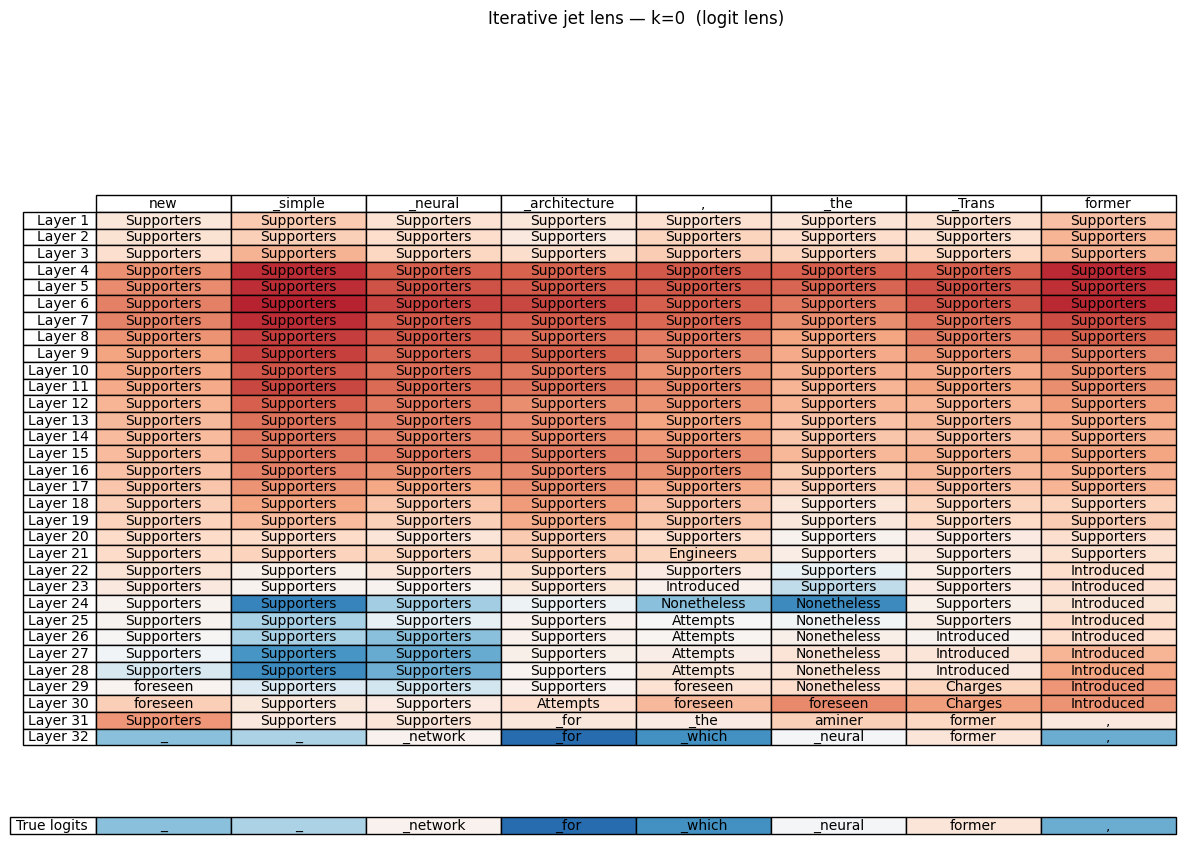

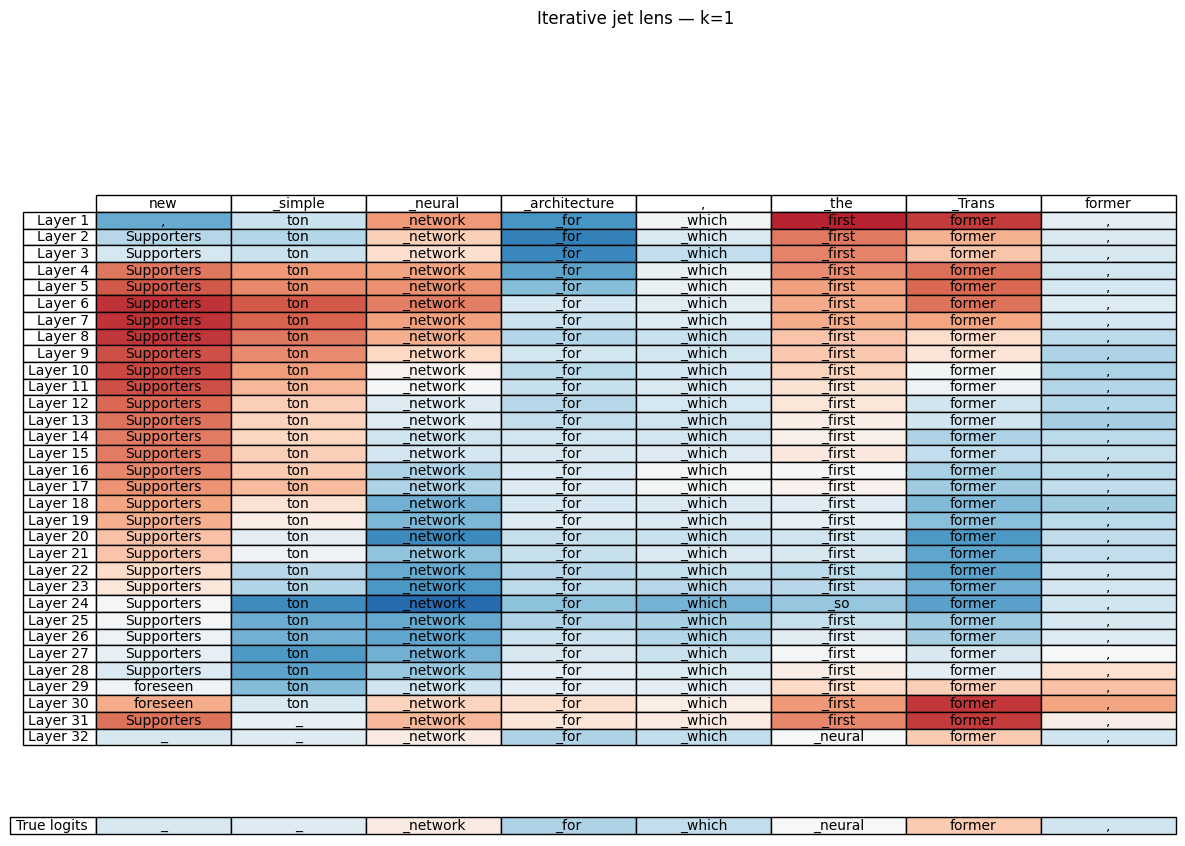

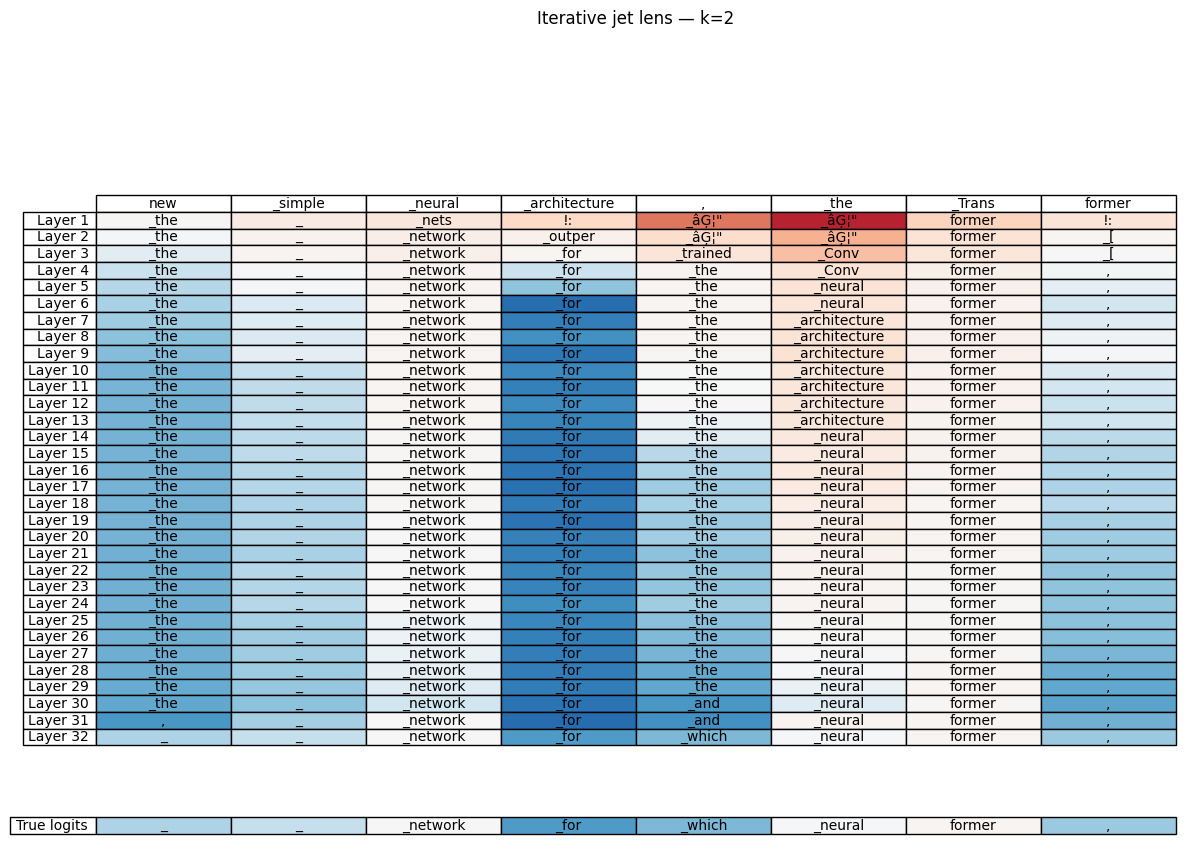

In [5]:
for k in [0, 1, 2]:
    lens = IterativeJetLenses(lm, layers, order=k)
    expansions, _ = lens(tokens)
    plot_lens_table(
        expansions,
        true_logits,
        tokens,
        lm,
        title=f"Iterative jet lens — k={k}{'  (logit lens)' if k == 0 else ''}",
        layer_indices=layers,
    )

## Cosine similarity by layer

How well does each layer's jet expansion approximate the true logits (last token position)?

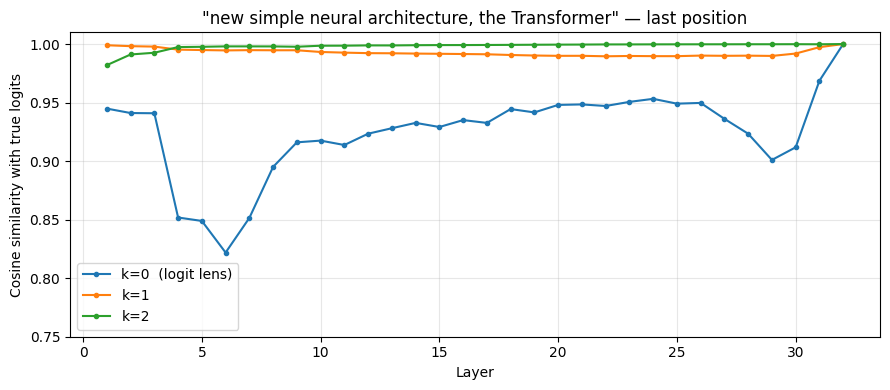

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4))
for k in [0, 1, 2]:
    lens = IterativeJetLenses(lm, layers, order=k)
    cos = lens.cosine_similarity(tokens)  # (n_layers, 1, seq_len)
    label = f"k={k}" + ("  (logit lens)" if k == 0 else "")
    ax.plot(layers, cos[:, 0, -1].detach().cpu().float(), label=label, marker="o", ms=3)

ax.set_xlabel("Layer")
ax.set_ylabel("Cosine similarity with true logits")
ax.set_title(f'"{sentence}" — last position')
ax.set_ylim((0.75, 1.01))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Joint jet lens

The joint lens decomposes the decoder output as a sum of terms, one per residual differential $\Delta h_l = h_l - h_{l-1}$:
$$
f(z) \approx \sum_{l} w_l(z)\, \hat{f}_{\Delta h_l}(z)
$$
Weights $w_l$ are learned per-token to minimise reconstruction error in logit space (using the $U^\top U$ metric to avoid applying the unembedding during backprop).

In [7]:
# load gpt2 since optimization is a bit quicker :)
model_name = "gpt2"
# model_name = "EleutherAI/gpt-neo-2.7B"
lm = models.from_pretrained(model_name)
layers = list(range(1, lm.depth + 1))

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

k=0  loss: 466948.7812 → 441932.1562


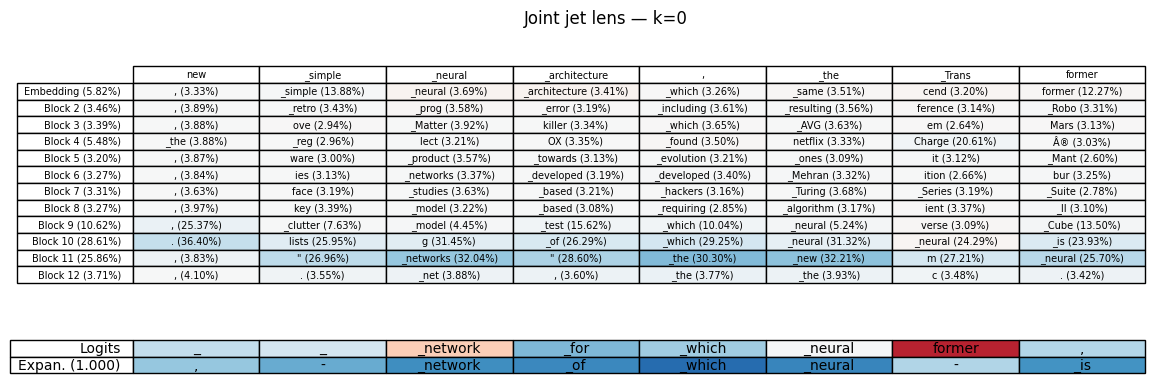

k=1  loss: 75339.1172 → 3363.3357


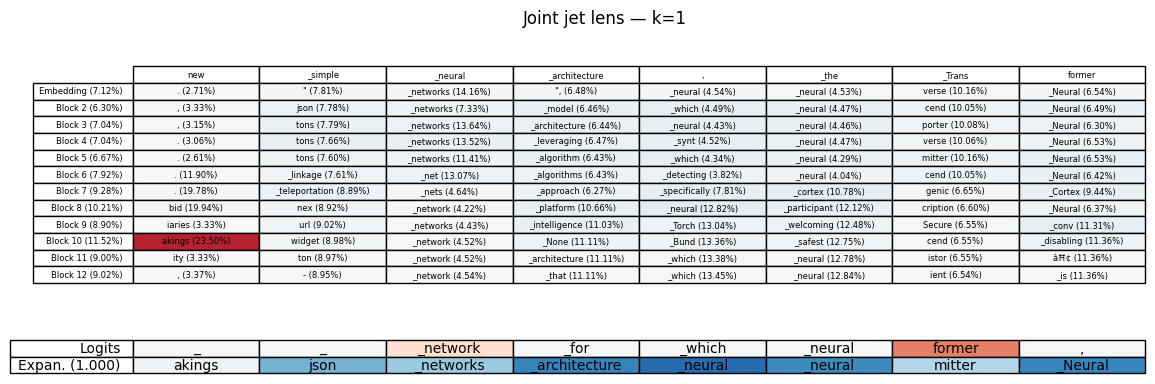

In [8]:
lenses = {}
for k in [0, 1]:
    lens = JointJetLens(lm, layers, order=k)
    losses = lens.optimize_weights(tokens, lr=1e-2, iters=100)
    print(f"k={k}  loss: {losses[0]:.4f} → {losses[-1]:.4f}")
    lenses[k] = lens

    combined, per_center = lens.jet_logits(tokens)
    cos_sim = lens.cosine_similarity(tokens).item()

    plot_joint_lens_table(
        per_center,
        combined,
        true_logits,
        tokens,
        lm,
        weights=lens.weights,
        cos_sim=cos_sim,
        layer_indices=layers,
        title=f"Joint jet lens — k={k}",
    )

### Weight distribution across layers

Which layers get the most weight after optimization?

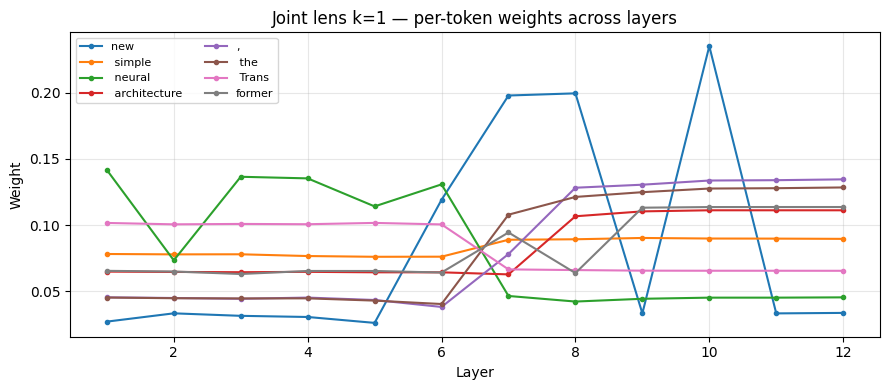

In [9]:
import matplotlib.pyplot as plt

w = lenses[1].weights.detach().float()  # (n_layers, seq_len)
token_strs = [
    t.replace("Ġ", " ") for t in lm.tokenizer.convert_ids_to_tokens(tokens[0].tolist())
]

fig, ax = plt.subplots(figsize=(9, 4))
for j, tok in enumerate(token_strs):
    ax.plot(layers, w[:, j].cpu(), label=tok, marker="o", ms=3)
ax.set_xlabel("Layer")
ax.set_ylabel("Weight")
ax.set_title("Joint lens k=1 — per-token weights across layers")
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()